# Basic data loading and manipulation

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
%%time

try:
    housing_metrics_df = pd.read_csv('RDC_Inventory_Core_Metrics_Monthly_County_from_201601.csv')
except:
    housing_metrics_df = pd.read_csv('https://raw.githubusercontent.com/mdelventhal/econphd-codecamp/refs/heads/main/lesson/09_data/RDC_Inventory_Core_Metrics_Monthly_County_from_201601.csv')

housing_metrics_df

CPU times: total: 531 ms
Wall time: 541 ms


,month_date_yyyymm,county_fips,county_name,median_listing_price,active_listing_count,median_days_on_market,new_listing_count,price_reduced_count,price_reduced_share,pending_listing_count,median_listing_price_per_square_foot,median_square_feet,average_listing_price,total_listing_count
0,202606,6087,"santa cruz, ca",1293750.0,468,48.0,200,136.0,0.1645,194.0,734.0,1697.0,1698772.0,653
1,202606,26059,"hillsdale, mi",349900.0,126,54.0,42,46.0,0.2071,51.0,180.0,1768.0,377652.0,177
2,202606,37177,"tyrrell, nc",235000.0,7,42.0,0,0.0,0.0000,1.0,166.0,1614.0,245976.0,8
3,202606,37117,"martin, nc",184800.0,49,86.0,6,16.0,0.1984,20.0,111.0,1574.0,206202.0,68
4,202606,13289,"twiggs, ga",164900.0,11,36.0,2,2.0,0.1111,2.0,149.0,1488.0,232936.0,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372491,201607,21069,"fleming, ky",229000.0,9,92.0,0,0.0,0.0000,1.0,111.0,2005.0,214300.0,10
372492,201607,19087,"henry, ia",145000.0,52,79.0,16,8.0,0.0800,29.0,84.0,1626.0,181879.0,82
372493,201607,48443,"terrell, tx",74900.0,3,107.0,0,0.0,0.0000,NaN,54.0,1400.0,72768.0,3
372494,201607,39159,"union, oh",370000.0,207,58.0,88,80.0,0.1699,145.0,134.0,2866.0,426540.0,343


In [10]:
housing_metrics_df['date'] = pd.to_datetime(housing_metrics_df.month_date_yyyymm,format='%Y%m')
housing_metrics_df['year'] = housing_metrics_df['date'].dt.year
housing_metrics_df['month'] = housing_metrics_df['date'].dt.month
housing_metrics_df['log_median_listing_price'] = np.log(housing_metrics_df['median_listing_price'])

housing_metrics_df[['county_name','month_date_yyyymm','date','year','month','median_listing_price','log_median_listing_price']]

,county_name,month_date_yyyymm,date,year,month,median_listing_price,log_median_listing_price
0,"santa cruz, ca",202606,2026-06-01,2026,6,1293750.0,14.073056
1,"hillsdale, mi",202606,2026-06-01,2026,6,349900.0,12.765403
2,"tyrrell, nc",202606,2026-06-01,2026,6,235000.0,12.367341
3,"martin, nc",202606,2026-06-01,2026,6,184800.0,12.127029
4,"twiggs, ga",202606,2026-06-01,2026,6,164900.0,12.013095
...,...,...,...,...,...,...,...
372491,"fleming, ky",201607,2016-07-01,2016,7,229000.0,12.341477
372492,"henry, ia",201607,2016-07-01,2016,7,145000.0,11.884489
372493,"terrell, tx",201607,2016-07-01,2016,7,74900.0,11.223909
372494,"union, oh",201607,2016-07-01,2016,7,370000.0,12.821258


In [11]:
housing_metrics_df[['county_name',
                    'month_date_yyyymm','date','year','month',
                    'median_listing_price','log_median_listing_price']].sort_values(by=['county_name','date'])

,county_name,month_date_yyyymm,date,year,month,median_listing_price,log_median_listing_price
371071,"abbeville, sc",201607,2016-07-01,2016,7,149900.0,11.917724
369158,"abbeville, sc",201608,2016-08-01,2016,8,179950.0,12.100434
363986,"abbeville, sc",201609,2016-09-01,2016,9,177075.0,12.084329
362149,"abbeville, sc",201610,2016-10-01,2016,10,167200.0,12.026946
357325,"abbeville, sc",201611,2016-11-01,2016,11,167725.0,12.030081
...,...,...,...,...,...,...,...
125819,"ziebach, sd",202302,2023-02-01,2023,2,248500.0,12.423198
121472,"ziebach, sd",202303,2023-03-01,2023,3,248500.0,12.423198
120904,"ziebach, sd",202304,2023-04-01,2023,4,248500.0,12.423198
115156,"ziebach, sd",202306,2023-06-01,2023,6,75000.0,11.225243


<Axes: >

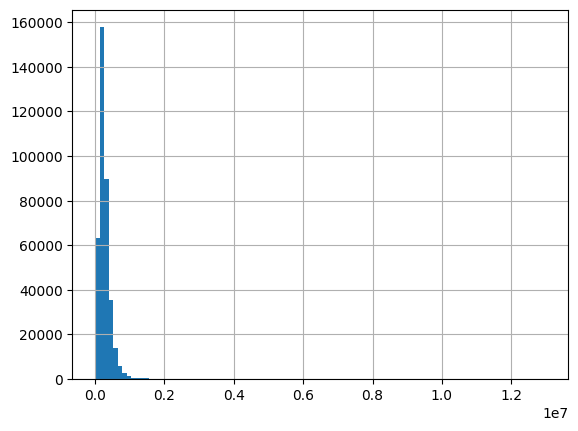

In [12]:
housing_metrics_df.median_listing_price.hist(bins=100)

<Axes: >

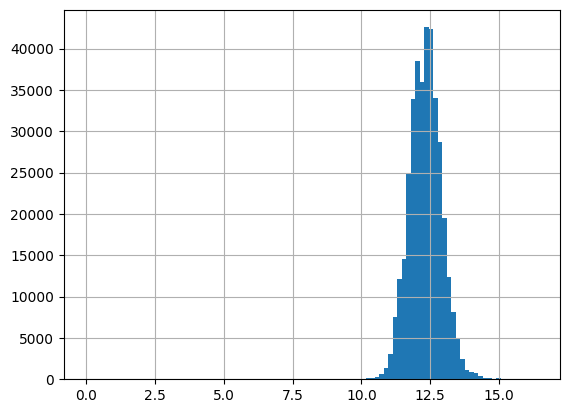

In [13]:
housing_metrics_df.log_median_listing_price.hist(bins=100)

In [14]:
pivoted_log_median_listing_price = housing_metrics_df.loc[housing_metrics_df.county_name.isin(['los angeles, ca','harris, tx'])].pivot(index='date',
                                                                                                    columns='county_name',
                                                                                                    values='log_median_listing_price')

pivoted_log_median_listing_price

county_name,"harris, tx","los angeles, ca"
date,,
2016-07-01,12.676045,13.457406
2016-08-01,12.660010,13.429775
2016-09-01,12.643886,13.422468
2016-10-01,12.611534,13.422468
2016-11-01,12.611204,13.422241
...,...,...
2026-02-01,12.696694,13.784020
2026-03-01,12.706545,13.802425
2026-04-01,12.717392,13.806974


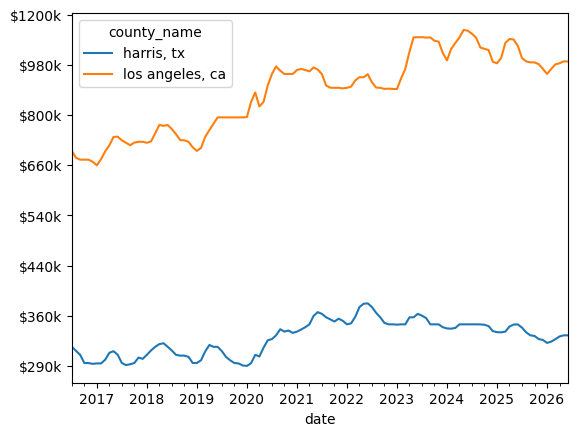

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# Define a function to convert values to thousands (K)
def format_log_house_dollars(x, pos):
    return f'${10*int(np.exp(x) / 10000):.0f}k'



f,ax = plt.subplots()



pivoted_log_median_listing_price.plot(ax=ax)
ax.yaxis.set_major_formatter(FuncFormatter(format_log_house_dollars))

plt.show()

In [16]:
pivoted_median_listing_price = housing_metrics_df.loc[housing_metrics_df.county_name.isin(['los angeles, ca','harris, tx'])].pivot(index='date',
                                                                                                    columns='county_name',
                                                                                                    values='median_listing_price')

pivoted_change_since_2016 = pivoted_median_listing_price/pivoted_median_listing_price.iloc[0]-1

pivoted_change_since_2016

county_name,"harris, tx","los angeles, ca"
date,,
2016-07-01,0.000000,0.000000
2016-08-01,-0.015907,-0.027253
2016-09-01,-0.031648,-0.034335
2016-10-01,-0.062474,-0.034335
2016-11-01,-0.062783,-0.034554
...,...,...
2026-02-01,0.020863,0.386266
2026-03-01,0.030970,0.412017
2026-04-01,0.042214,0.418455


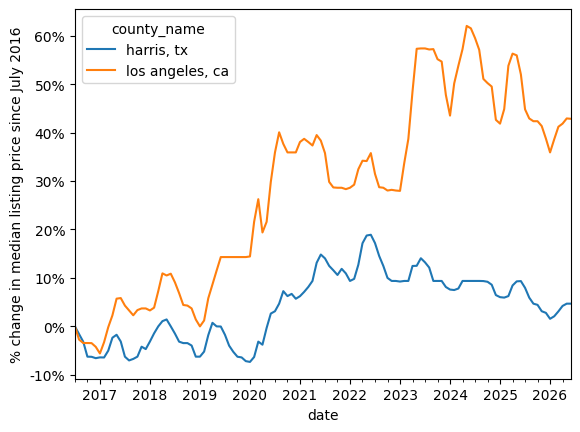

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter



def format_percent(x, pos,digits=0):
    return f'{100*x:.{digits}f}%'
    
f,ax = plt.subplots()



pivoted_change_since_2016.plot(ax=ax)

ax.yaxis.set_major_formatter(FuncFormatter(format_percent))
ax.set_ylabel('% change in median listing price since July 2016')
plt.show()

In [18]:
pivoted_log_median_listing_price = housing_metrics_df.loc[housing_metrics_df.county_name.isin(['los angeles, ca','harris, tx'])].pivot(index='date',
                                                                                                    columns='county_name',
                                                                                                    values='log_median_listing_price')

pivoted_log_median_listing_price = pivoted_log_median_listing_price.reset_index()
pivoted_log_median_listing_price['year'] = pivoted_log_median_listing_price.date.dt.year
pivoted_log_median_listing_price['month'] = pivoted_log_median_listing_price.date.dt.month
pivoted_log_median_listing_price['float_date'] = pivoted_log_median_listing_price['year'] + (pivoted_log_median_listing_price['month']-1)/12


for county in ['harris, tx','los angeles, ca']:
    m4,m3,m2,m1,b = np.polyfit(pivoted_log_median_listing_price['float_date'], 
                     pivoted_log_median_listing_price[county], 
                     4)
    pivoted_log_median_listing_price[county + ' trend'] = m4*pivoted_log_median_listing_price['float_date']**4\
                                                            + m3*pivoted_log_median_listing_price['float_date']**3\
                                                            + m2*pivoted_log_median_listing_price['float_date']**2\
                                                            + m1*pivoted_log_median_listing_price['float_date']**1\
                                                            + b
    pivoted_log_median_listing_price[county + ' de-trended'] = pivoted_log_median_listing_price[county] - pivoted_log_median_listing_price[county + ' trend']
    pivoted_log_median_listing_price[county + ' seasonally-adjusted'] = pivoted_log_median_listing_price[county] - \
        pivoted_log_median_listing_price[['month']].merge(pivoted_log_median_listing_price[['month',county + ' de-trended']].groupby('month').mean().reset_index(),
                                                          how='left',
                                                          left_on='month',
                                                          right_on='month'
                                                         )[county + ' de-trended'].values

pivoted_log_median_listing_price

county_name,date,"harris, tx","los angeles, ca",year,month,float_date,"harris, tx trend","harris, tx de-trended","harris, tx seasonally-adjusted","los angeles, ca trend","los angeles, ca de-trended","los angeles, ca seasonally-adjusted"
0,2016-07-01,12.676045,13.457406,2016,7,2016.500000,12.668939,0.007106,12.660919,13.422005,0.035401,13.432023
1,2016-08-01,12.660010,13.429775,2016,8,2016.583333,12.661685,-0.001675,12.656289,13.425716,0.004059,13.420178
2,2016-09-01,12.643886,13.422468,2016,9,2016.666667,12.655050,-0.011164,12.647013,13.429486,-0.007018,13.427224
3,2016-10-01,12.611534,13.422468,2016,10,2016.750000,12.649009,-0.037475,12.622978,13.433321,-0.010853,13.433272
4,2016-11-01,12.611204,13.422241,2016,11,2016.833333,12.643535,-0.032331,12.622143,13.437218,-0.014977,13.437899
...,...,...,...,...,...,...,...,...,...,...,...,...
115,2026-02-01,12.696694,13.784020,2026,2,2026.083333,12.710468,-0.013774,12.713532,13.811414,-0.027394,13.805987
116,2026-03-01,12.706545,13.802425,2026,3,2026.166667,12.707233,-0.000688,12.708744,13.804980,-0.002554,13.796694
117,2026-04-01,12.717392,13.806974,2026,4,2026.250000,12.704036,0.013356,12.701825,13.798111,0.008863,13.789219
118,2026-05-01,12.721886,13.814510,2026,5,2026.333333,12.700899,0.020987,12.696900,13.790799,0.023711,13.781205


<Axes: xlabel='date'>

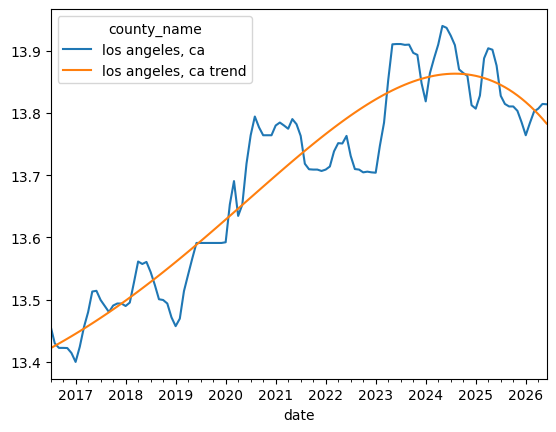

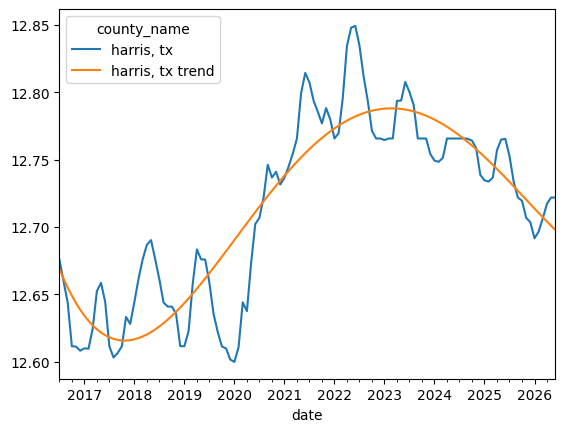

In [19]:
pivoted_log_median_listing_price.plot(x='date',y=['los angeles, ca','los angeles, ca trend'	])
pivoted_log_median_listing_price.plot(x='date',y=['harris, tx','harris, tx trend'	])

<Axes: xlabel='date'>

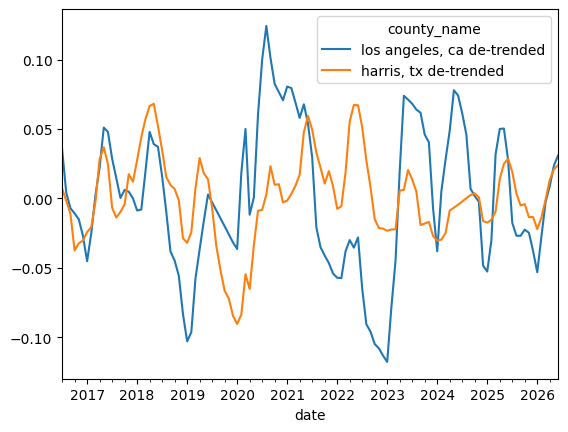

In [20]:
pivoted_log_median_listing_price.plot(x='date',y=['los angeles, ca de-trended','harris, tx de-trended'	])


In [21]:
pivoted_log_median_listing_price[['month'] + [county + ' de-trended' for county in ['harris, tx','los angeles, ca']]].groupby('month').mean()

county_name,"harris, tx de-trended","los angeles, ca de-trended"
month,,
1,-0.022155,-0.043201
2,-0.016838,-0.021967
3,-0.002199,0.005732
4,0.015567,0.017755
5,0.024985,0.033305
6,0.027718,0.037839
7,0.015126,0.025383
8,0.003721,0.009596
9,-0.003128,-0.004756


<Axes: xlabel='date'>

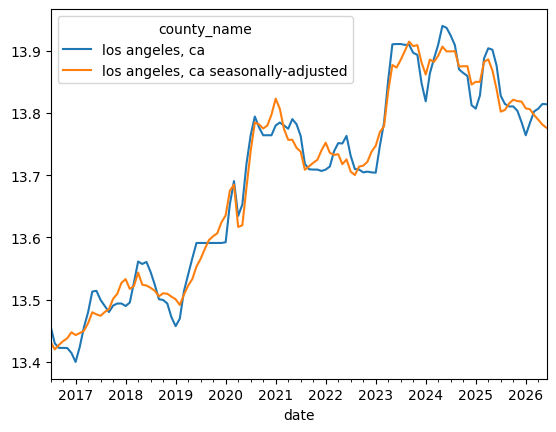

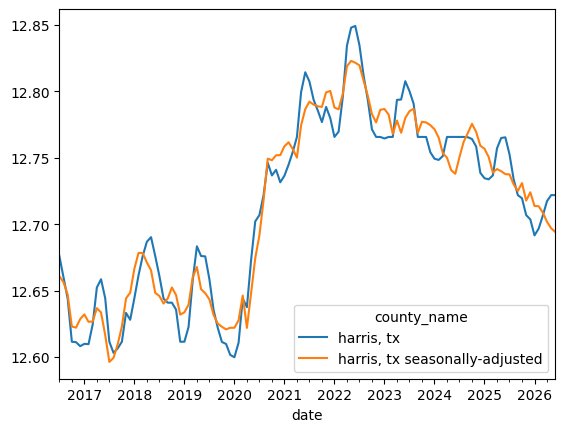

In [22]:
pivoted_log_median_listing_price.plot(x='date',y=['los angeles, ca','los angeles, ca seasonally-adjusted'	])
pivoted_log_median_listing_price.plot(x='date',y=['harris, tx','harris, tx seasonally-adjusted'	])

In [23]:
housing_metrics_df

,month_date_yyyymm,county_fips,county_name,median_listing_price,active_listing_count,median_days_on_market,new_listing_count,price_reduced_count,price_reduced_share,pending_listing_count,median_listing_price_per_square_foot,median_square_feet,average_listing_price,total_listing_count,date,year,month,log_median_listing_price
0,202606,6087,"santa cruz, ca",1293750.0,468,48.0,200,136.0,0.1645,194.0,734.0,1697.0,1698772.0,653,2026-06-01,2026,6,14.073056
1,202606,26059,"hillsdale, mi",349900.0,126,54.0,42,46.0,0.2071,51.0,180.0,1768.0,377652.0,177,2026-06-01,2026,6,12.765403
2,202606,37177,"tyrrell, nc",235000.0,7,42.0,0,0.0,0.0000,1.0,166.0,1614.0,245976.0,8,2026-06-01,2026,6,12.367341
3,202606,37117,"martin, nc",184800.0,49,86.0,6,16.0,0.1984,20.0,111.0,1574.0,206202.0,68,2026-06-01,2026,6,12.127029
4,202606,13289,"twiggs, ga",164900.0,11,36.0,2,2.0,0.1111,2.0,149.0,1488.0,232936.0,14,2026-06-01,2026,6,12.013095
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372491,201607,21069,"fleming, ky",229000.0,9,92.0,0,0.0,0.0000,1.0,111.0,2005.0,214300.0,10,2016-07-01,2016,7,12.341477
372492,201607,19087,"henry, ia",145000.0,52,79.0,16,8.0,0.0800,29.0,84.0,1626.0,181879.0,82,2016-07-01,2016,7,11.884489
372493,201607,48443,"terrell, tx",74900.0,3,107.0,0,0.0,0.0000,NaN,54.0,1400.0,72768.0,3,2016-07-01,2016,7,11.223909
372494,201607,39159,"union, oh",370000.0,207,58.0,88,80.0,0.1699,145.0,134.0,2866.0,426540.0,343,2016-07-01,2016,7,12.821258


In [24]:
aggregated_national_listing_counts = housing_metrics_df.groupby('date')[['active_listing_count','price_reduced_count']].sum()

aggregated_national_listing_counts


,active_listing_count,price_reduced_count
date,,
2016-07-01,1463418,409188.0
2016-08-01,1456770,408044.0
2016-09-01,1443454,397032.0
2016-10-01,1404200,369344.0
2016-11-01,1336964,309334.0
...,...,...
2026-02-01,912610,256022.0
2026-03-01,945532,294200.0
2026-04-01,999250,322782.0


<Axes: xlabel='date'>

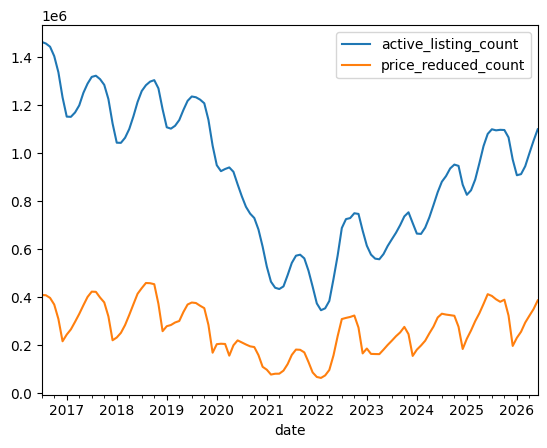

In [25]:
aggregated_national_listing_counts.plot()

<Axes: xlabel='date'>

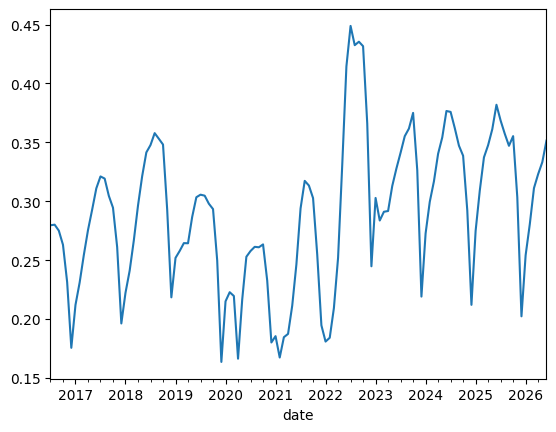

In [26]:
aggregated_national_listing_counts['frac_reduced_price'] = aggregated_national_listing_counts.price_reduced_count/aggregated_national_listing_counts.active_listing_count


aggregated_national_listing_counts['frac_reduced_price'].plot()

In [ ]:
def weighted_aggregate_prepare_output(df,target_col,groupby_cols=None,weight_col=None,reshape=False):
    if not reshape:
        if groupby_cols is None: df_to_out = df[[]].copy()
        else: df_to_out = df[groupby_cols].copy()
    else:
        if groupby_cols is None: df_to_out = df.loc[[0],[]].copy()
        else: df_to_out = df[groupby_cols].groupby(groupby_cols).max().reset_index()
    return df_to_out

def weighted_median(df,target_col,groupby_cols=None,weight_col=None,reshape=False):
    
    df_to_out = weighted_aggregate_prepare_output(df,target_col,groupby_cols=groupby_cols,weight_col=weight_col,reshape=reshape)
        
    if (groupby_cols is None) and (weight_col is None):
        df_to_out['median'] = df[target_col].median()
    elif (weight_col is None):
        df_to_out['median'] = df_to_out.merge(df[groupby_cols + [target_col]].groupby(groupby_cols).agg({target_col:'median'}).reset_index(),
                                              how='left',
                                              left_on=groupby_cols,
                                              right_on=groupby_cols
                                             )
    elif (groupby_cols is None):
        df_to_median = df[[target_col,weight_col]].copy()
        df_to_median = df_to_median.sort_values(by=target_col).reset_index(drop=True)
        df_to_median['percentile'] = df_to_median[weight_col].cumsum()/ df_to_median[weight_col].sum()
        below_median = df_to_median.percentile - .5 <= 0
        above_median = df_to_median.percentile - .5 > 0
        m = (df_to_median.loc[above_median,target_col].iloc[0] - df_to_median.loc[below_median,target_col].iloc[-1])\
                /(df_to_median.loc[above_median,'percentile'].iloc[0] - df_to_median.loc[below_median,'percentile'].iloc[-1])
        b = df_to_median.loc[below_median,target_col].iloc[-1] - m*df_to_median.loc[below_median,'percentile'].iloc[-1]
        df_to_out['median'] = m*0.5 + b
    else:
        df_to_median = df[groupby_cols + [target_col,weight_col]].copy()
        df_to_median = df_to_median.sort_values(by=groupby_cols + [target_col]).reset_index(drop=True)
        df_to_median['grouped_weightsums'] = df_to_median[groupby_cols].merge(df_to_median.groupby(groupby_cols)[weight_col].sum().reset_index(),
                                                                              how='left',
                                                                              left_on=groupby_cols,
                                                                              right_on=groupby_cols
                                                                             )[weight_col].values
        df_to_median['percentile'] = df_to_median.groupby(groupby_cols)[weight_col].cumsum()/df_to_median['grouped_weightsums']
        df_to_median['__index'] = df_to_median.index.copy()
        below_median_inds = df_to_median.loc[df_to_median.percentile - .5 <= 0].groupby(groupby_cols)['__index'].max()
        above_median_inds = df_to_median.loc[df_to_median.percentile - .5 > 0].groupby(groupby_cols)['__index'].min()
        m = (df_to_median.iloc[above_median_inds].groupby(groupby_cols)[target_col].max() - df_to_median.iloc[below_median_inds].groupby(groupby_cols)[target_col].max()) \
                /(df_to_median.iloc[above_median_inds].groupby(groupby_cols)['percentile'].max() - df_to_median.iloc[below_median_inds].groupby(groupby_cols)['percentile'].max())
        b = df_to_median.iloc[below_median_inds].groupby(groupby_cols)[target_col].max() - m*df_to_median.iloc[below_median_inds].groupby(groupby_cols)['percentile'].max()
        df_to_out['median'] = df_to_out.merge((m*0.5 + b).reset_index(),
                                              how='left',
                                              left_on=groupby_cols,
                                              right_on=groupby_cols
                                             )[0].values
    return df_to_out['median']

def weighted_mean(df,target_col,groupby_cols=None,weight_col=None,reshape=False):
    
    df_to_out = weighted_aggregate_prepare_output(df,target_col,groupby_cols=groupby_cols,weight_col=weight_col,reshape=reshape)

        
    if (groupby_cols is None) and (weight_col is None):
        df_to_out['mean'] = df[target_col].mean()
    elif (weight_col is None):
        df_to_out['mean'] = df_to_out.merge(df[groupby_cols + [target_col]].groupby(groupby_cols).agg({target_col:'mean'}).reset_index(),
                                              how='left',
                                              left_on=groupby_cols,
                                              right_on=groupby_cols
                                             )
    elif (groupby_cols is None):
        df_to_mean = df[[target_col,weight_col]].copy()
        df_to_out['mean'] = (df_to_mean[target_col]*df_to_mean[weight_col]).sum()/df_to_mean[weight_col].sum()
    else:
        df_to_mean = df[groupby_cols + [target_col,weight_col]].copy()
        df_to_mean['weighted_sumands'] = df_to_mean[target_col]*df_to_mean[weight_col]
        df_to_out['mean'] =  df_to_out.merge(
                                ((df_to_mean[groupby_cols + ['weighted_sumands']]).groupby(groupby_cols).sum().rename(columns={'weighted_sumands':0})\
                                    /df_to_mean[groupby_cols + [weight_col]].groupby(groupby_cols).sum().rename(columns={weight_col:0})).reset_index(),
                                how='left',
                                left_on=groupby_cols,
                                right_on=groupby_cols)[0].values
        
    return df_to_out['mean']


